In [34]:
#import necessary modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import contextily as ctx
import plotly.express as px
import xarray as xr
import dask
import scipy.stats as stats
import json
import os
from matplotlib.colors import Normalize
import imageio.v2 as imageio
import geopandas as gpd 
pd.set_option('display.max_columns', None)


In [2]:
# load the data
fish_data = pd.read_csv('Larvae.csv')
# convert into dataframe
fish_df = pd.DataFrame(fish_data)
# display the first few rows of the data
fish_df.head()

,cruise,ship,ship_code,order_occupied,tow_type,tow_number,net_location,time,latitude,longitude,line,station,standard_haul_factor,volume_sampled,proportion_sorted,scientific_name,common_name,itis_tsn,calcofi_species_code,larvae_count,larvae_10m2,larvae_100m3
0,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Citharichthys,Sanddabs,172715,924,2.0,3.30,NaN
1,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Engraulis mordax,Northern anchovy,161828,31,103.0,169.95,NaN
2,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Gobiidae,Gobies,171746,795,1.0,1.65,NaN
3,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Leuroglossus stilbius,California smoothtongue,162096,72,134.0,221.10,NaN
4,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Lipolagus ochotensis,Popeye blacksmelt,623625,68,1.0,1.65,NaN


Overview of columns in the data
===================================
| Column Name | Description | Interpretation / Units |
| :--- | :--- | :--- |
| **cruise** | Expedition identifier | Formatted as `YYYYMM` (Year and Month). Identifies the specific quarterly research cruise. |
| **ship** | Research vessel name | The full name of the ship used for the tow (e.g., "New Horizon", "David Starr Jordan"). |
| **ship_code** | Short-hand vessel ID | A unique NOAA/NODC alphanumeric code assigned to the research vessel. |
| **order_occupied** | Station sequence | The sequential order in which stations were visited during that specific cruise. |
| **tow_type** | Sampling method | Method of net deployment: **Oblique** (angled from depth to surface), **Vertical** (straight up), or **Surface** (Manta nets). |
| **tow_number** | Event ID | The specific ID number of the net tow at that station. |
| **net_location** | Net position | For multi-net arrays (like Bongo nets), this indicates if the sample came from the Port (P) or Starboard (S) net. |
| **time** | Timestamp | The date and time (UTC) when the tow was initiated. |
| **latitude** | Geographic Latitude | Decimal degrees (North); positive values represent the California Current region. |
| **longitude** | Geographic Longitude | Decimal degrees (West); usually represented as negative numbers in ERDDAP. |
| **line** | CalCOFI Line | The planned transect line number (perpendicular to the coast). |
| **station** | CalCOFI Station | The planned station number along the line (increasing values move further offshore). |
| **standard_haul_factor** | Calculation constant | A multiplier used to convert the raw count into a "per unit area" value (e.g., per 10m²). |
| **volume_sampled** | Water volume | The total cubic meters ($m^3$) of water filtered through the net, measured by a flowmeter. |
| **proportion_sorted** | Sub-sampling ratio | The fraction of the total sample that was actually sorted for larvae (1.0 = 100% sorted). |
| **scientific_name** | Taxon name | The formal Latin name of the fish larvae species identified. |
| **common_name** | Vernacular name | The common English name for the fish species (e.g., "Pacific Sardine"). |
| **itis_tsn** | Taxonomic Serial Number | The unique ID from the *Integrated Taxonomic Information System* for precise species tracking. |
| **calcofi_species_code** | Internal ID | The legacy 3-digit numeric code used by the CalCOFI program to categorize species. |
| **larvae_count** | Raw abundance | The actual number of individual larvae counted in the sorted portion of the sample. |
| **larvae_10m2** | Standardized abundance | The estimated number of larvae under 10 square meters of sea surface. (Calculated using the `standard_haul_factor`). |
| **larvae_100m3** | Volumetric abundance | The estimated number of larvae per 100 cubic meters of water strained. |

In [3]:
# show number of rows and columns in the data
# fish_df.shape         # should see 385733 rows, 22 columns

# show total number of unique species in the data via common_name
# fish_df['common_name'].nunique()         # 651 unique species in the data

# list of all the column names
# fish_df.columns

# show percentage of missing values in the larvae_100m3 column
# fish_df['larvae_100m3'].isnull().mean() * 100         # over 93% of the values 
                                                        #in this column are missing

# see number of times 924 appears in the calcofi_species_code column
# fish_df['calcofi_species_code'].value_counts()[924]

# see number of missing values in common_name column
# fish_df['common_name'].isnull().sum() 
# see number of missing values in scientific_name column
# fish_df['scientific_name'].isnull().sum()        
# so scientific name has 0 missing but common name has quite a few

#find top 5 most common species in the data by scientific name, then list them out with common name and count

/var/folders/0y/mmp_lnms4tx1tvdz0cwsqdx40000gs/T/ipykernel_73474/2328733304.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_924_df['time'] = pd.to_datetime(species_924_df['time'])
/var/folders/0y/mmp_lnms4tx1tvdz0cwsqdx40000gs/T/ipykernel_73474/2328733304.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_924_df['year'] = species_924_df['time'].dt.year


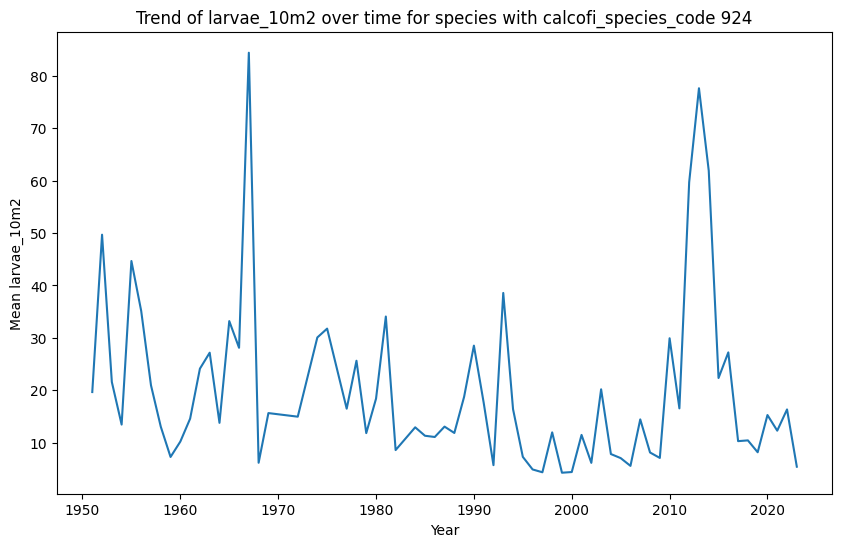

In [4]:
# show trend of larvae_10m2 column over time for the species with calcofi_species_code 924
# filter the data for the species with calcofi_species_code 924
species_924_df = fish_df[fish_df['calcofi_species_code'] == 924]

# group the data by year and calculate the mean of larvae_10m2 for each year, need to first convert time column to datetime format and extract the year
species_924_df['time'] = pd.to_datetime(species_924_df['time'])
species_924_df['year'] = species_924_df['time'].dt.year
yearly_trend_924 = species_924_df.groupby('year')['larvae_10m2'].mean()

# plot the trend over time
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_trend_924.index, y=yearly_trend_924.values)
plt.title('Trend of larvae_10m2 over time for species with calcofi_species_code 924')
plt.xlabel('Year')
plt.ylabel('Mean larvae_10m2')
plt.show()

In [5]:
import pandas as pd
import numpy as np

# 1. TEMPORAL CLEANING: Extracting standard time formats
# Convert 'time' to datetime, coercing errors to NaT (Not a Time)
fish_df['time'] = pd.to_datetime(fish_df['time'], errors='coerce')

# Extract 'year' and 'month' for easy decades/seasonal grouping
fish_df['year'] = fish_df['time'].dt.year
fish_df['month'] = fish_df['time'].dt.month

# 2. FIXING THE DENSITY NaNs: Recalculating missing metrics
# Step A: Estimate the total larvae in the net (handling zeroes to avoid division errors)
# If proportion_sorted is 0 or NaN, we'll replace it temporarily with 1 to avoid inf values
safe_proportion = fish_df['proportion_sorted'].replace({0: np.nan}).fillna(1)
estimated_total_larvae = fish_df['larvae_count'] / safe_proportion

# Step B: Recalculate larvae_100m3 (per 100 cubic meters)
# Formula: (Total Larvae / Volume Sampled) * 100
safe_volume = fish_df['volume_sampled'].replace({0: np.nan}) # Prevent division by zero
calculated_100m3 = (estimated_total_larvae / safe_volume) * 100

# Step C: Recalculate larvae_10m2 (per 10 square meters of sea surface)
# Formula: Total Larvae * Standard Haul Factor
calculated_10m2 = estimated_total_larvae * fish_df['standard_haul_factor']

# Step D: Fill the NaNs in the original columns with our calculated values
fish_df['larvae_100m3'] = fish_df['larvae_100m3'].fillna(calculated_100m3)
fish_df['larvae_10m2'] = fish_df['larvae_10m2'].fillna(calculated_10m2)

# Clean up infinite values created by any weird data quirks
fish_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. SPATIAL CLEANING: Prepping for mapping/visualization
# Drop rows that don't have valid coordinates
fish_df = fish_df.dropna(subset=['latitude', 'longitude'])

# 4. TAXONOMIC CLEANING: Handling missing names
# If common_name is missing, fill it with the scientific_name
fish_df['common_name'] = fish_df['common_name'].fillna(fish_df['scientific_name'])
# If both are missing, label as 'Unidentified'
fish_df['common_name'] = fish_df['common_name'].fillna('Unidentified')
fish_df['scientific_name'] = fish_df['scientific_name'].fillna('Unidentified')

# 5. FINAL CHECK 
print("Data Cleaning Complete.")
print(f"Remaining rows: {len(fish_df)}")
print(f"Percentage of missing 'larvae_100m3' values: {fish_df['larvae_100m3'].isna().mean() * 100:.2f}%")

# Display the first few rows of the cleaned data
display(fish_df.head())

Data Cleaning Complete.
Remaining rows: 385733
Percentage of missing 'larvae_100m3' values: 0.00%


,cruise,ship,ship_code,order_occupied,tow_type,tow_number,net_location,time,latitude,longitude,line,station,standard_haul_factor,volume_sampled,proportion_sorted,scientific_name,common_name,itis_tsn,calcofi_species_code,larvae_count,larvae_10m2,larvae_100m3,year,month
0,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Citharichthys,Sanddabs,172715,924,2.0,3.30,0.224065,1951,1
1,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Engraulis mordax,Northern anchovy,161828,31,103.0,169.95,11.539323,1951,1
2,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Gobiidae,Gobies,171746,795,1.0,1.65,0.112032,1951,1
3,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Leuroglossus stilbius,California smoothtongue,162096,72,134.0,221.10,15.012324,1951,1
4,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Lipolagus ochotensis,Popeye blacksmelt,623625,68,1.0,1.65,0.112032,1951,1


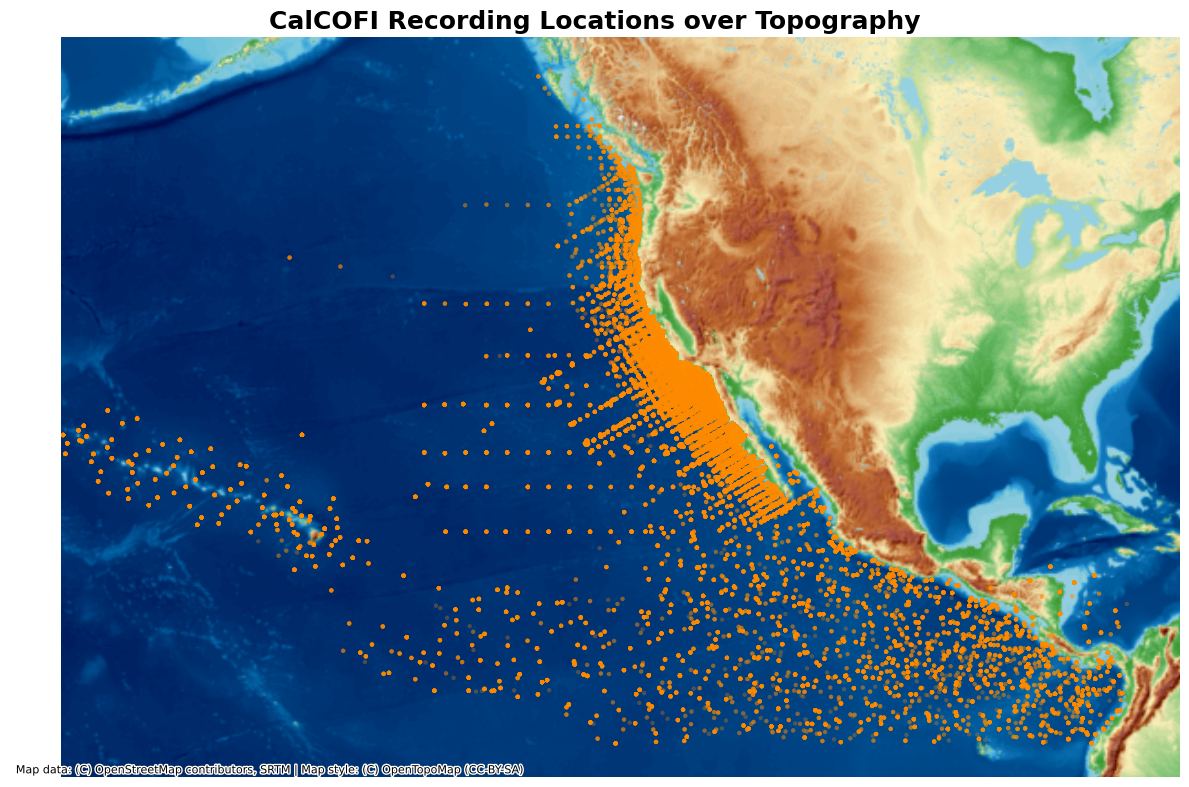

In [6]:
# =========================================================
# VISUALIZATION 1: Geographical Plotting of Cruise Paths
# =========================================================

# 1. Convert our Pandas DataFrame into a GeoDataFrame 
# EPSG:4326 is the standard coordinate reference system for Lat/Lon
gdf = gpd.GeoDataFrame(
    fish_df, 
    geometry=gpd.points_from_xy(fish_df.longitude, fish_df.latitude),
    crs="EPSG:4326"
)

# 2. Convert to Web Mercator (EPSG:3857) 
# Map tile providers (like Contextily) require Web Mercator projection to align properly
gdf_web_mercator = gdf.to_crs(epsg=3857)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the points (adjust 'markersize' and 'alpha' depending on how dense your data is)
gdf_web_mercator.plot(ax=ax, markersize=10, color='darkorange', alpha=0.3, edgecolor='none')

# Add the topographic background using Contextily's OpenTopoMap provider
# This will automatically bound itself to the extent of your data (San Diego / SoCal coast)
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

ax.set_title('CalCOFI Recording Locations over Topography', fontsize=18, fontweight='bold')
plt.axis('off') # Hide the raw axis numbers since the map is visual
plt.tight_layout()
plt.show()

Straight lines near the California and Western US coast depict the CalCOFI sampling grid, The program was designed to survey specific perpendicular "lines" and "stations." The goal was to eliminate geographic variables: by visiting the exact same GPS coordinates year after year, scientists could confidently say that any changes in fish larvae numbers were due to actual population/environmental shifts, not just because they sampled a different patch of ocean. 

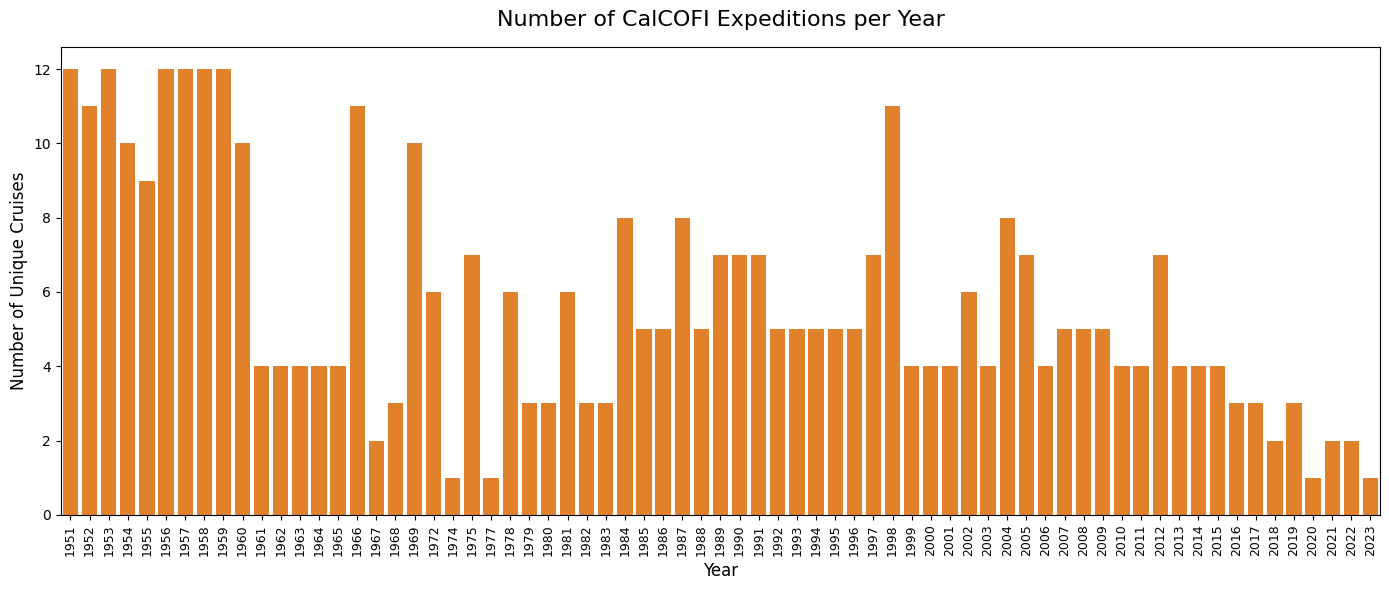

In [7]:
# =========================================================
# PLOT 2: Number of Expeditions Over the Years
# =========================================================
plt.figure(figsize=(14, 6))

# Group by year and count the number of UNIQUE cruises per year
# We use 'nunique()' because one cruise has thousands of rows of fish data
expeditions_per_year = fish_df.groupby('year')['cruise'].nunique().reset_index()
expeditions_per_year.rename(columns={'cruise': 'cruise_count'}, inplace=True)

# Create a bar plot
sns.barplot(
    data=expeditions_per_year, 
    x='year', 
    y='cruise_count', 
    color='#ff7f0e'
)

plt.title('Number of CalCOFI Expeditions per Year', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Unique Cruises', fontsize=12)

# Rotate the x-axis labels so the years are legible
plt.xticks(rotation=90, fontsize=9)
# Show every 2nd year on the x-axis to prevent crowding if needed, 
# but seaborn's default with rotated labels usually handles decades well.

plt.tight_layout()
plt.show()

Original dataset rows: 385733
Core CalCOFI dataset rows: 362576


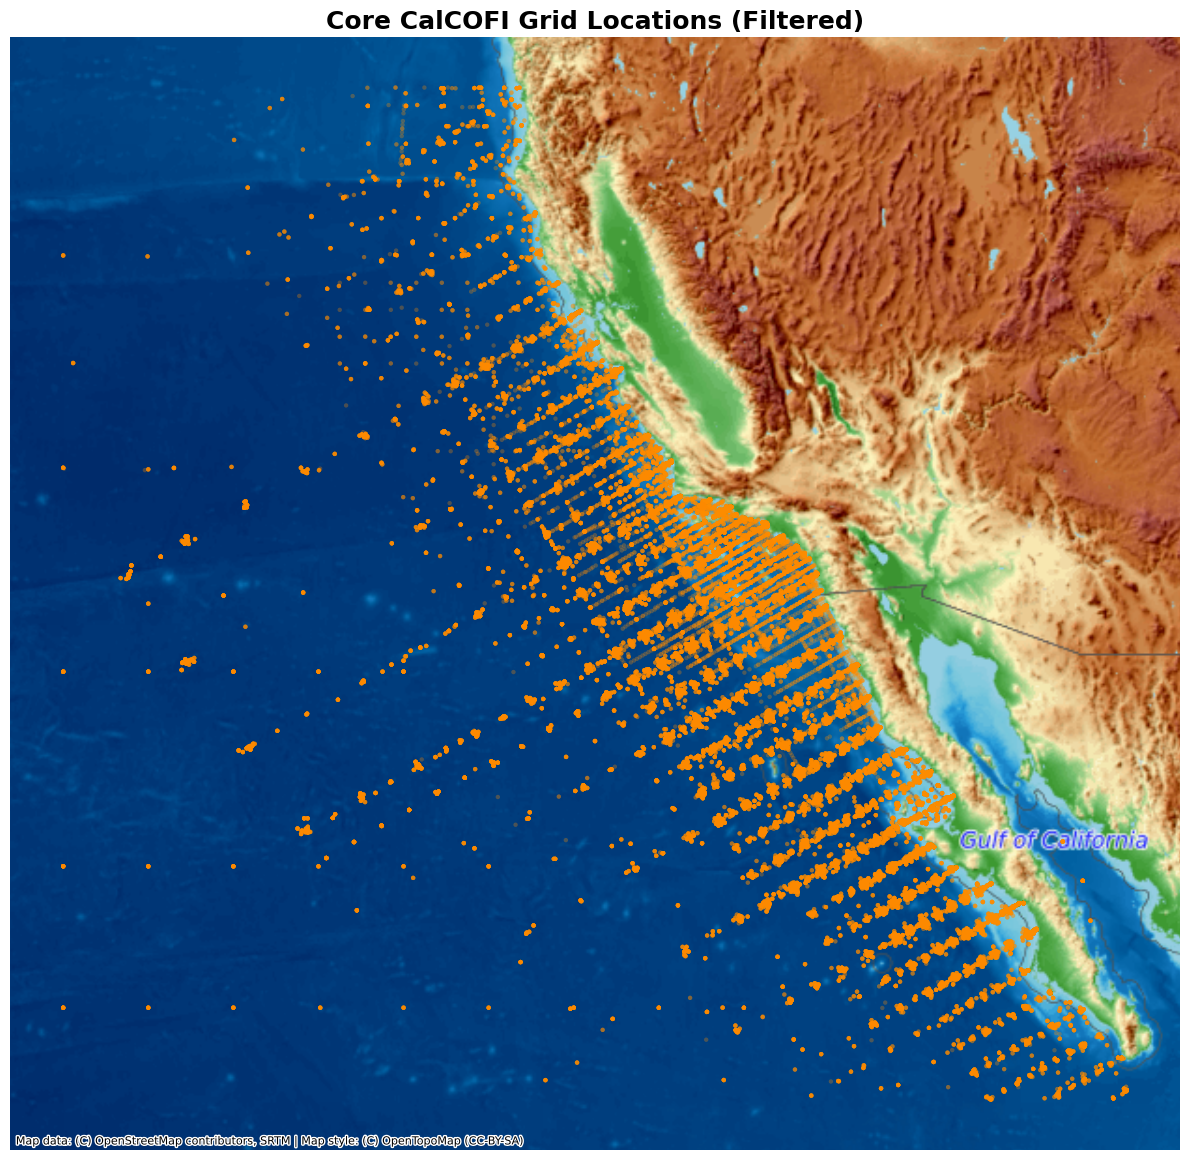

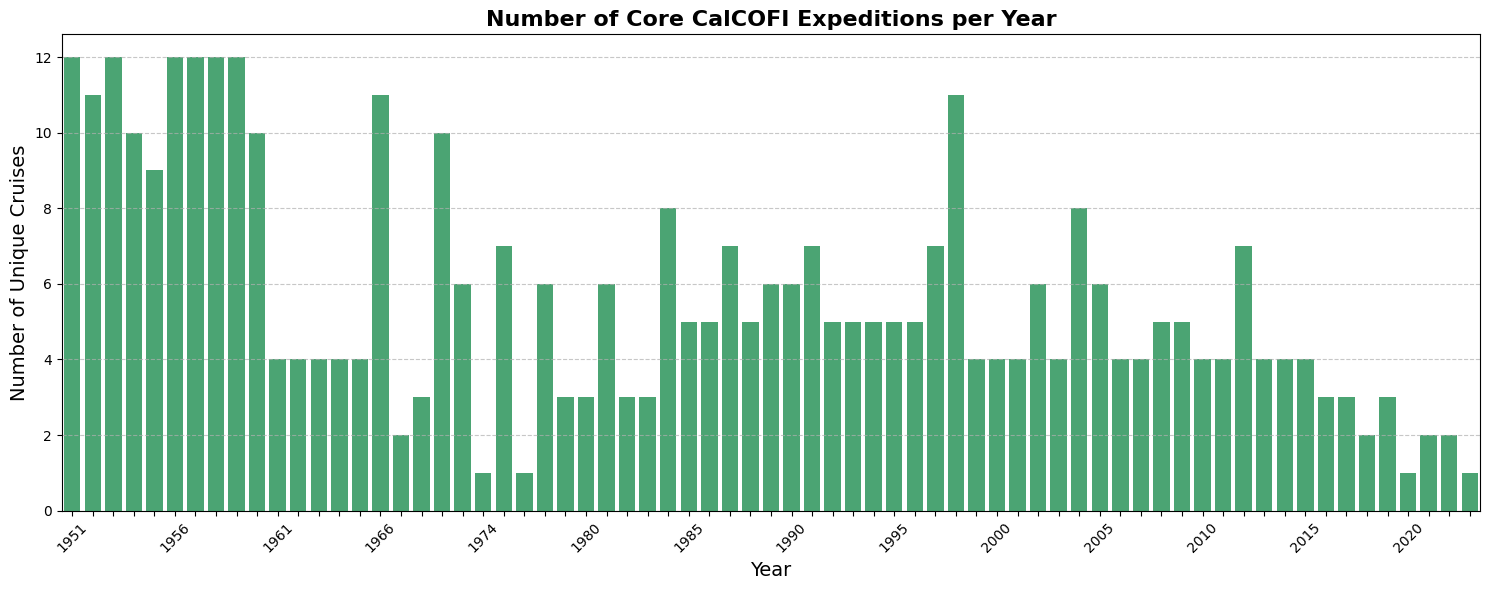

In [8]:
# =========================================================
# 1. FILTERING: Creating the Core CalCOFI Dataset
# =========================================================

# Apply a geographic bounding box around the US West Coast / Baja
# and ensure 'line' and 'station' values exist.
calcofi_core_df = fish_df[
    (fish_df['latitude'] >= 22.0) & (fish_df['latitude'] <= 42.0) & 
    (fish_df['longitude'] >= -135.0) & (fish_df['longitude'] <= -110.0)
].copy()

# Drop rows that don't have an official CalCOFI line/station grid assignment
calcofi_core_df = calcofi_core_df.dropna(subset=['line', 'station'])

print(f"Original dataset rows: {len(fish_df)}")
print(f"Core CalCOFI dataset rows: {len(calcofi_core_df)}")

# =========================================================
# 2. VISUALIZATION 1: Updated Geographical Map
# =========================================================

# Convert our filtered DataFrame into a GeoDataFrame 
gdf_core = gpd.GeoDataFrame(
    calcofi_core_df, 
    geometry=gpd.points_from_xy(calcofi_core_df.longitude, calcofi_core_df.latitude),
    crs="EPSG:4326"
)

# Convert to Web Mercator for the Contextily basemap
gdf_core_web = gdf_core.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

# Plot the filtered points
gdf_core_web.plot(ax=ax, markersize=10, color='darkorange', alpha=0.3, edgecolor='none')

# Add topographic background
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

ax.set_title('Core CalCOFI Grid Locations (Filtered)', fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# =========================================================
# 3. VISUALIZATION 2: Updated Expeditions per Year
# =========================================================

# Group by Year and count the unique cruises in the FILTERED dataset
expeditions_per_year_core = calcofi_core_df.groupby('year')['cruise'].nunique().reset_index()
expeditions_per_year_core.rename(columns={'cruise': 'num_expeditions'}, inplace=True)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(
    data=expeditions_per_year_core, 
    x='year', 
    y='num_expeditions', 
    color='mediumseagreen', # Changed color to distinguish from the first plot 
    ax=ax
)

# Clean up the x-axis to show every 5th year
plt.xticks(rotation=45)
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 5 == 0:  
        label.set_visible(True)
    else:
        label.set_visible(False)

ax.set_title('Number of Core CalCOFI Expeditions per Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Number of Unique Cruises', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Budget cuts in 60s and 70s caused CalCOFI to reduce total number of voyages, instead had to pivot to doing 1-2 years without many cruises into a year with a lot of cruises. Modern day decline is due to budget cuts, COVID (specifically 2020), and issues with maintanence.

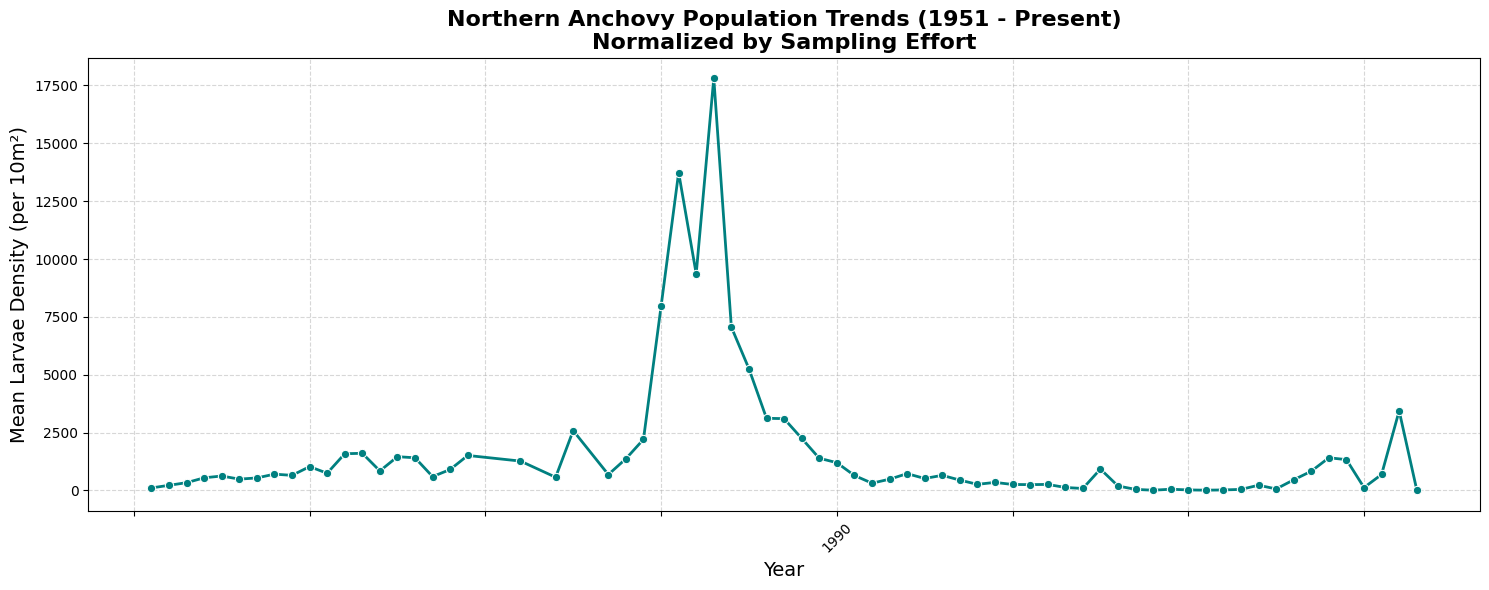

In [9]:
# =========================================================
# 1. NORMALIZING EFFORT & CALCULATING ANCHOVY DENSITY
# =========================================================

# Create a unique identifier for every single net tow (Cruise + Station combination)
# This prevents us from double-counting if a station was recorded multiple times for different species
calcofi_core_df['sampling_event'] = calcofi_core_df['cruise'].astype(str) + "_" + calcofi_core_df['station'].astype(str)

# Calculate the total number of unique tows conducted per year (our "Effort")
effort_per_year = calcofi_core_df.groupby('year')['sampling_event'].nunique().reset_index()
effort_per_year.rename(columns={'sampling_event': 'total_tows'}, inplace=True)

# Isolate only the Northern anchovy data
anchovy_df = calcofi_core_df[calcofi_core_df['scientific_name'] == 'Engraulis mordax'].copy()

# Sum the total larvae_10m2 for anchovies per year
anchovy_sum_per_year = anchovy_df.groupby('year')['larvae_10m2'].sum().reset_index()
anchovy_sum_per_year.rename(columns={'larvae_10m2': 'total_anchovy_density'}, inplace=True)

# Merge our effort and our catch together
anchovy_trend = pd.merge(effort_per_year, anchovy_sum_per_year, on='year', how='left')

# If there were years where NO anchovies were caught, fill the NaNs with 0
anchovy_trend['total_anchovy_density'] = anchovy_trend['total_anchovy_density'].fillna(0)

# Calculate the actual normalized metric: Mean Density per Tow
anchovy_trend['mean_density_per_tow'] = anchovy_trend['total_anchovy_density'] / anchovy_trend['total_tows']

# =========================================================
# 2. PLOTTING THE TIMELINE
# =========================================================

fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    data=anchovy_trend, 
    x='year', 
    y='mean_density_per_tow', 
    marker='o', 
    color='teal', 
    linewidth=2,
    ax=ax
)

# Formatting the graph
ax.set_title('Northern Anchovy Population Trends (1951 - Present)\nNormalized by Sampling Effort', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Mean Larvae Density (per 10m²)', fontsize=14)
ax.grid(axis='both', linestyle='--', alpha=0.5)

# Tidy up the x-axis
plt.xticks(rotation=45)
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 5 == 0:  
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
# Create our new dataframe starting from the core dataset we made earlier
cleaned_fish_df = calcofi_core_df.copy()

# =========================================================
# 1. SPATIAL BIAS: Filtering to the "Core 66" Stations
# =========================================================
# The standard modern CalCOFI grid consists of 6 specific lines (76.7 to 93.3)
# and stations from the coast out to station 120.0.
valid_lines = [76.7, 80.0, 83.3, 86.7, 90.0, 93.3]

# Round the lines to 1 decimal place to avoid floating point precision errors
cleaned_fish_df['line'] = cleaned_fish_df['line'].round(1)

# Apply the spatial bounding box
cleaned_fish_df = cleaned_fish_df[
    (cleaned_fish_df['line'].isin(valid_lines)) & 
    (cleaned_fish_df['station'] <= 120.0)
]

# =========================================================
# 2. MATHEMATICAL SKEWNESS: Log Transformation
# =========================================================
# numpy's log1p function computes ln(1 + x) safely and efficiently.
# This pulls extreme spikes (like your 17,000 count) closer to the rest of the data.
cleaned_fish_df['log_larvae_10m2'] = np.log1p(cleaned_fish_df['larvae_10m2'])
cleaned_fish_df['log_larvae_100m3'] = np.log1p(cleaned_fish_df['larvae_100m3'])

# =========================================================
# 3. SEASONAL GAPS: Assigning Seasons for Balanced Averaging
# =========================================================
# We extract the 'quarter' of the year to serve as our meteorological seasons.
# Q1: Winter, Q2: Spring, Q3: Summer, Q4: Fall
cleaned_fish_df['season'] = cleaned_fish_df['time'].dt.quarter

# =========================================================
# 4. EXTRA CRUCIAL CLEANING: Deduplication & Sanity Checks
# =========================================================
# Drop completely duplicated rows (common in large database merges)
cleaned_fish_df = cleaned_fish_df.drop_duplicates()

# Ensure no negative larvae counts slipped through from sensor errors
cleaned_fish_df = cleaned_fish_df[cleaned_fish_df['larvae_count'] >= 0]

# =========================================================
# FINAL OUTPUT
# =========================================================
print(f"Data processing complete.")
print(f"Final 'cleaned_fish_df' rows: {len(cleaned_fish_df)}")

# Display the first few rows to verify the new columns
display(cleaned_fish_df[['cruise', 'year', 'season', 'line', 'station', 'scientific_name', 'larvae_10m2', 'log_larvae_10m2']].head())

Data processing complete.
Final 'cleaned_fish_df' rows: 157524


,cruise,year,season,line,station,scientific_name,larvae_10m2,log_larvae_10m2
0,195101,1951,1,86.7,35.0,Citharichthys,3.30,1.458615
1,195101,1951,1,86.7,35.0,Engraulis mordax,169.95,5.141371
2,195101,1951,1,86.7,35.0,Gobiidae,1.65,0.974560
3,195101,1951,1,86.7,35.0,Leuroglossus stilbius,221.10,5.403128
4,195101,1951,1,86.7,35.0,Lipolagus ochotensis,1.65,0.974560


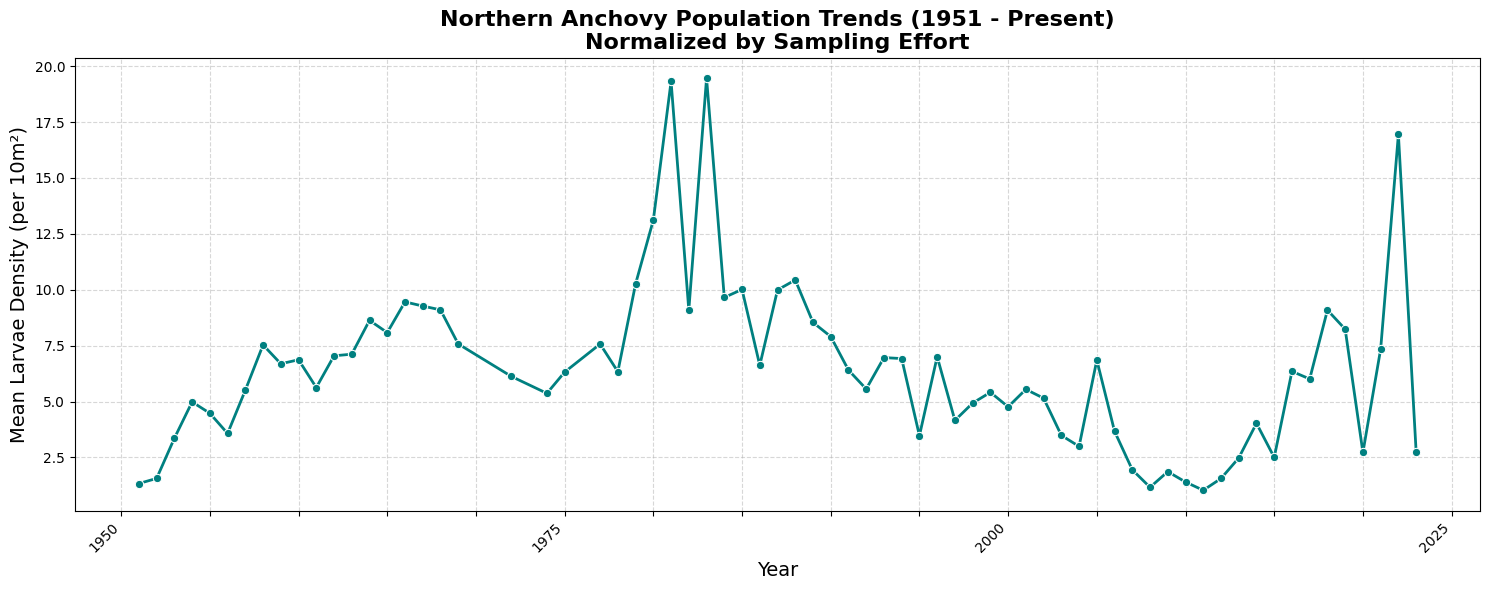

In [11]:
cleaned_fish_df['sampling_event'] = cleaned_fish_df['cruise'].astype(str) + "_" + cleaned_fish_df['station'].astype(str)
effort_per_year = cleaned_fish_df.groupby('year')['sampling_event'].nunique().reset_index()
effort_per_year.rename(columns={'sampling_event': 'total_tows'}, inplace=True)
anchovy_df = cleaned_fish_df[cleaned_fish_df['scientific_name'] == 'Engraulis mordax'].copy()

anchovy_sum_per_year = anchovy_df.groupby('year')['log_larvae_10m2'].sum().reset_index()
anchovy_sum_per_year.rename(columns={'log_larvae_10m2': 'total_anchovy_density'}, inplace=True)

anchovy_trend = pd.merge(effort_per_year, anchovy_sum_per_year, on='year', how='left')

anchovy_trend['total_anchovy_density'] = anchovy_trend['total_anchovy_density'].fillna(0)

anchovy_trend['mean_density_per_tow'] = anchovy_trend['total_anchovy_density'] / anchovy_trend['total_tows']


fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(
    data=anchovy_trend, 
    x='year', 
    y='mean_density_per_tow', 
    marker='o', 
    color='teal', 
    linewidth=2,
    ax=ax
)

# Formatting the graph
ax.set_title('Northern Anchovy Population Trends (1951 - Present)\nNormalized by Sampling Effort', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Mean Larvae Density (per 10m²)', fontsize=14)
ax.grid(axis='both', linestyle='--', alpha=0.5)

min_year = int(anchovy_trend['year'].min())
max_year = int(anchovy_trend['year'].max())
start_tick = min_year - (min_year % 5)
xticks = np.arange(start_tick, max_year + 5, 5) 

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45, ha='right')

# Tidy up the x-axis
plt.xticks(rotation=45)
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 5 == 0:  
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.tight_layout()
plt.show()

https://www.calcofi.com/publications/calcofireports/v21/Vol_21_Stauffer___Parker.pdf?utm_source=chatgpt.com

https://www.sciencedirect.com/science/article/pii/S0165783615301363


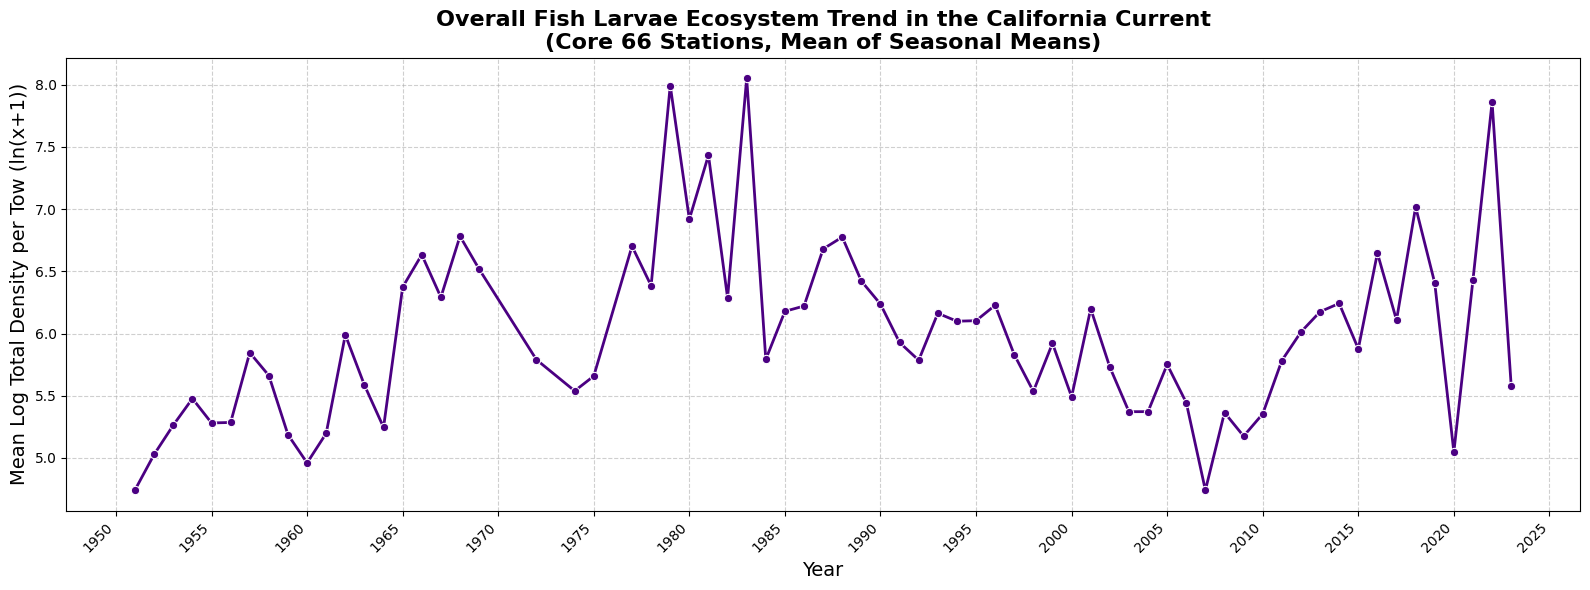

In [12]:
# =========================================================
# 1. CALCULATING TOTAL LARVAE PER TOW
# =========================================================
# Group by our unique tow identifier ('sampling_event'), plus year and season.
# We sum the raw 'larvae_10m2' of ALL species caught in that single net tow.
tows_df = cleaned_fish_df.groupby(['sampling_event', 'year', 'season'])['larvae_10m2'].sum().reset_index()
tows_df.rename(columns={'larvae_10m2': 'total_larvae_10m2'}, inplace=True)

# =========================================================
# 2. LOG TRANSFORMATION ON THE TOTALS
# =========================================================
# Now that we have the total ecosystem catch per tow, we apply our log1p 
# transformation to pull in the extreme outliers (like massive spawning events).
tows_df['log_total_larvae'] = np.log1p(tows_df['total_larvae_10m2'])

# =========================================================
# 3. BALANCING THE SEASONS (Mean of Seasonal Means)
# =========================================================
# First, calculate the average log density for each season within each year.
seasonal_means = tows_df.groupby(['year', 'season'])['log_total_larvae'].mean().reset_index()

# Next, calculate the annual average by taking the mean of those seasonal averages.
# This prevents a year with 3 summer cruises and 1 winter cruise from artificially 
# skewing the annual data to look exactly like the summer.
annual_trend = seasonal_means.groupby('year')['log_total_larvae'].mean().reset_index()

# =========================================================
# 4. PLOTTING THE OVERALL TREND
# =========================================================
fig, ax = plt.subplots(figsize=(16, 6))

sns.lineplot(
    data=annual_trend, 
    x='year', 
    y='log_total_larvae', 
    marker='o', 
    color='indigo', 
    linewidth=2,
    ax=ax
)

# --- Fixing the X-Axis ---
# Find the start and end years in the dataset
min_year = int(annual_trend['year'].min())
max_year = int(annual_trend['year'].max())

# Create an array of years, stepping by exactly 5
# We subtract (min_year % 5) to snap the start year to a nice round number (e.g., 1950, 1955)
start_tick = min_year - (min_year % 5)
xticks = np.arange(start_tick, max_year + 5, 5) 

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45, ha='right')

# Formatting the graph
ax.set_title('Overall Fish Larvae Ecosystem Trend in the California Current\n(Core 66 Stations, Mean of Seasonal Means)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Mean Log Total Density per Tow (ln(x+1))', fontsize=14)
ax.grid(axis='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The Late 70s / Early 80s Spike caused by Pacific Decadal Oscillation (PDO) flip from cold to powerful warm phase. 1982-1983 also had a strong El Nino event that further increased the water temperature. This caused a spike in births/population of mesopelagic (deep-sea) fishes, leading to the spiking near that time.
https://www.pmel.noaa.gov/elnino/fish-distribution

The 90s to Early 2000s decline was likely caused by the continuing warming of the ocean, which caused the water column became more "stratified" (meaning layers of water stopped mixing as easily). Deep, nutrient-rich water can't upwell to the surface. Without nutrients, phytoplankton died off, zooplankton plummeted, and fish larvae that rely on them for food suffered a slow decline. 
https://pubmed.ncbi.nlm.nih.gov/17812604/

2008 drop was probably because of El Nina, which brings cold, nutrient-rich water that is generally good for adult fish. However, the accompnying winds and coastal might've blown larvae offshore and out of the Core 66 sampling grid.

2020 is probably a data artifact, lack of cruises in general but esp lack of Spring ones causes the data to look a bit wack.


In [13]:
top_species = cleaned_fish_df['scientific_name'].value_counts().head(5)
top_species_df = cleaned_fish_df[cleaned_fish_df['scientific_name'].isin(top_species.index)]
top_species_summary = top_species_df.groupby('scientific_name')['common_name'].first().reset_index()
top_species_summary['count'] = top_species_summary['scientific_name'].map(top_species)
top_species_summary = top_species_summary[['scientific_name', 'common_name', 'count']]
print(top_species_summary)

             scientific_name                                    common_name  \
0           Engraulis mordax  Northern anchovy                                
1      Leuroglossus stilbius  California smoothtongue                         
2    Protomyctophum crockeri  California flashlightfish                       
3                   Sebastes  Rockfishes                                      
4  Stenobrachius leucopsarus  Northern lampfish                               

   count  
0  11519  
1   6704  
2   6229  
3   9121  
4   7331  


In [14]:
# =========================================================
# 1. ISOLATE AND FILTER (Coastal Focus)
# =========================================================
anchovy_geo = cleaned_fish_df[cleaned_fish_df['scientific_name'] == 'Engraulis mordax'].copy()

# The 'station' variable tracks distance from shore. 
# Capping it at 90.0 removes the deep-water offshore points and keeps us close to the coast.
anchovy_geo = anchovy_geo[anchovy_geo['station'] <= 90.0]

# Create a clean, readable string for our animation slider
season_map = {1: 'Q1 (Winter)', 2: 'Q2 (Spring)', 3: 'Q3 (Summer)', 4: 'Q4 (Fall)'}
anchovy_geo['season_name'] = anchovy_geo['season'].map(season_map)
anchovy_geo['time_frame'] = anchovy_geo['year'].astype(str) + " - " + anchovy_geo['season_name']

# =========================================================
# 2. SPATIAL AGGREGATION & LOG TRANSFORMATION
# =========================================================
anchovy_geo['lat_bin'] = np.round(anchovy_geo['latitude'] * 2) / 2
anchovy_geo['lon_bin'] = np.round(anchovy_geo['longitude'] * 2) / 2

# Group by spatial bins and calculate the mean density
agg_anchovy = anchovy_geo.groupby(
    ['time_frame', 'year', 'season', 'lat_bin', 'lon_bin']
)['larvae_10m2'].mean().reset_index()

# APPLYING THE LOG SCALE: 
# Using log(x+1) for our bubble sizes to ensure non-boom years remain visible
agg_anchovy['log_larvae'] = np.log1p(agg_anchovy['larvae_10m2'])

# Sort chronologically
agg_anchovy = agg_anchovy.sort_values(by=['year', 'season'])

# =========================================================
# 3. GENERATING THE ANIMATION
# =========================================================
fig = px.scatter_mapbox(
    agg_anchovy,
    lat="lat_bin",
    lon="lon_bin",
    size="log_larvae",           # Size is now based on the log transformation
    color="log_larvae",          # Color shifts with the log transformation
    animation_frame="time_frame",
    color_continuous_scale=px.colors.sequential.Plasma,
    size_max=50,                 # Adjusted max size to fit the log scale beautifully 
    zoom=5.5,
    center={"lat": 32.5, "lon": -119.0}, # Shifted slightly east due to the coastal filter
    mapbox_style="carto-positron",
    title="Seasonal Timelapse: Northern Anchovy (Log Scale, Coastal Focus)",
    hover_data={'time_frame': False, 'year': False, 'season': False} 
)

# --- SPEEDING UP THE ANIMATION ---
# Access the animation buttons in Plotly's layout menu
# 'frame' duration is how long the data stays on screen (in milliseconds)
# 'transition' duration is the morphing animation time between frames
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100 
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 200 

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

/var/folders/0y/mmp_lnms4tx1tvdz0cwsqdx40000gs/T/ipykernel_73474/1393714240.py:36: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [15]:
sst_data = xr.open_dataset(
    "sst.mon.mean.nc",
    engine="netcdf4",
    chunks="auto"
)

# =========================================================
# 1. DEFINE OUR BOUNDING BOX (Converting Lon to 0-360)
# =========================================================
# Original CalCOFI Bounds: Lat 22 to 42, Lon -135 to -110
min_lat = 22.0
max_lat = 42.0

# Convert negative longitudes to the 0-360 scale
min_lon = -135.0 + 360.0  # 225.0
max_lon = -110.0 + 360.0  # 250.0

# =========================================================
# 2. LAZY SUBSETTING WITH XARRAY
# =========================================================
# We use .sel() and slice() to grab only the geographic box we need.
# Because the data is chunked, this takes almost zero memory!
sst_california_baja = sst_data.sel(
    lat=slice(min_lat, max_lat),
    lon=slice(min_lon, max_lon)
)

print(f"Original dataset size: {sst_data.nbytes / (1024**3):.2f} GB")
print(f"Subset dataset size: {sst_california_baja.nbytes / (1024**2):.2f} MB")

# =========================================================
# 3. CONVERT TO PANDAS DATAFRAME
# =========================================================
# Now that it's only a few megabytes, it is totally safe to pull into Pandas.
# We drop any NaN values (like pixels over dry land instead of ocean).
sst_df = sst_california_baja.to_dataframe().reset_index().dropna(subset=['sst'])

# =========================================================
# 4. FIX THE LONGITUDE FOR MERGING
# =========================================================
# Convert the 0-360 longitude back to the standard -180 to 180 format 
# so it matches our cleaned_fish_df perfectly!
sst_df['lon'] = sst_df['lon'] - 360.0

# Rename 'lon' to 'longitude' and 'lat' to 'latitude' to match the fish data
sst_df.rename(columns={'lon': 'longitude', 'lat': 'latitude'}, inplace=True)

# Display the clean result
display(sst_df)

Original dataset size: 2.07 GB
Subset dataset size: 16.33 MB


,time,latitude,longitude,sst
0,1981-09-01,22.125,-134.875,24.208000
1,1981-09-01,22.125,-134.625,24.223000
2,1981-09-01,22.125,-134.375,24.169333
3,1981-09-01,22.125,-134.125,24.070333
4,1981-09-01,22.125,-133.875,23.946999
...,...,...,...,...
4279938,2026-03-01,41.875,-125.375,11.982903
4279939,2026-03-01,41.875,-125.125,12.074839
4279940,2026-03-01,41.875,-124.875,11.922903
4279941,2026-03-01,41.875,-124.625,11.641935


Merge successful! Total matched observations: 2546


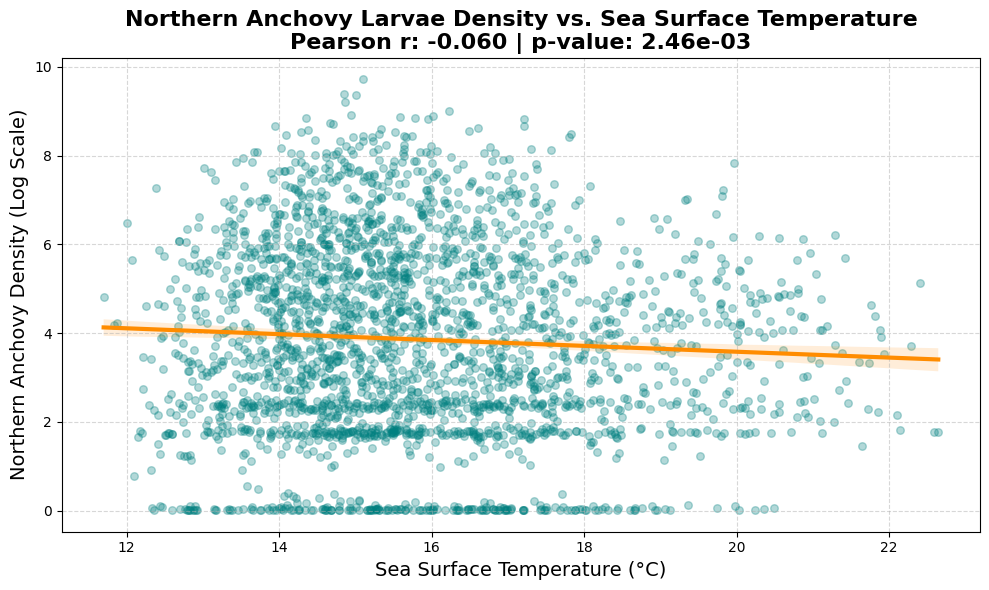

In [16]:
# =========================================================
# 1. PREP THE SST DATA (Temporal & Spatial Binning)
# =========================================================
# Extract year and season (quarter) to match CalCOFI
sst_df['year'] = sst_df['time'].dt.year
sst_df['season'] = sst_df['time'].dt.quarter

# Snap the 0.25-degree SST grid to our 0.5-degree Anchovy grid
sst_df['lat_bin'] = np.round(sst_df['latitude'] * 2) / 2
sst_df['lon_bin'] = np.round(sst_df['longitude'] * 2) / 2

# Calculate the mean temperature for each spatial bin during each season
agg_sst = sst_df.groupby(['year', 'season', 'lat_bin', 'lon_bin'])['sst'].mean().reset_index()

# =========================================================
# 2. MERGE THE DATASETS
# =========================================================
# We perform an 'inner' join. This links rows where the year, season, and location all match perfectly.
# Note: This will naturally filter out fish data prior to late 1981.
merged_df = pd.merge(agg_anchovy, agg_sst, on=['year', 'season', 'lat_bin', 'lon_bin'], how='inner')

print(f"Merge successful! Total matched observations: {len(merged_df)}")

# =========================================================
# 3. REGRESSION & CORRELATION ANALYSIS
# =========================================================
# Calculate the Pearson correlation coefficient and the p-value
# We use the log_larvae metric because the raw density is too skewed for standard regression
corr, p_value = stats.pearsonr(merged_df['sst'], merged_df['log_larvae'])

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Seaborn's regplot automatically calculates and plots a linear regression line with a confidence interval
sns.regplot(
    data=merged_df, 
    x='sst', 
    y='log_larvae', 
    scatter_kws={'alpha': 0.3, 'color': 'teal', 's': 30}, # 's' is dot size
    line_kws={'color': 'darkorange', 'linewidth': 3},
    ax=ax
)

# Formatting
ax.set_title(
    f'Northern Anchovy Larvae Density vs. Sea Surface Temperature\n'
    f'Pearson r: {corr:.3f} | p-value: {p_value:.2e}', 
    fontsize=16, fontweight='bold'
)
ax.set_xlabel('Sea Surface Temperature (°C)', fontsize=14)
ax.set_ylabel('Northern Anchovy Density (Log Scale)', fontsize=14)
ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Gap between the 0 and 2 for the density is due to how we used log transforms to manipulate the density. When we have very small values (only 1-2 estimated anchovies per 10 m^2), the log transformation (ln(x + 1)) causes those values to become inflated, which means that because it is physically impossible to catch between 0 and 1 larva, it is mathematically impossible to generate a raw density between 0 and ~3.0 if we used singular site measurements only. However, because we aggregated sites together and thus have some decimal values for the fish density, there are still some values floating in that "forbiddin zone".

Low Pearson R is indicator that the data is very spread out and doesn't hug the line. Pretty expected considering how messy this data can be.

Very low p-val is indicator that there is significance: Higher temperatures do scale with lower Northern anchovy larvae density/population

Cloud of values above the 14-17 degrees celsius range, potentially most optimal temperature window?

Warm water cliff: Past 18 degrees celsius we see the density values significantly decrease.



In [ ]:
# =========================================================
# 1. SETUP & DATA PREP
# =========================================================
output_folder = "timelapse_frames_with_map"
os.makedirs(output_folder, exist_ok=True)

# Load the built-in world map from Geopandas
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
# To show ALL ocean water, we must use the original agg_sst dataframe,
# and match the time labels to our merged_df time labels.
agg_sst['time_label'] = agg_sst['year'].astype(str) + " - Season " + agg_sst['season'].astype(str)
merged_df['time_label'] = merged_df['year'].astype(str) + " - Season " + merged_df['season'].astype(str)

# Get the list of chronological time frames based on the anchovy data
time_frames = sorted(merged_df['time_label'].unique().tolist())

# Lock the colorbars so they don't shift between frames
sst_norm = Normalize(vmin=10.0, vmax=22.0)
anchovy_norm = Normalize(vmin=0.0, vmax=9.0)

frame_filenames = []

print(f"Generating {len(time_frames)} frames with full map. This may take a moment...")

# =========================================================
# 2. THE GENERATOR LOOP
# =========================================================
for i, time_period in enumerate(time_frames):
    
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    # Give the axis a pale blue background in case there are missing SST grid cells
    ax.set_facecolor('#e0f3ff') 
    
    # --- LAYER 0: The Land Map ---
    # Plot the world map (we will zoom in on California later)
    world.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.8, zorder=1)
    
    # --- LAYER 1: Full Ocean SST Background ---
    # We pull from agg_sst to get the ENTIRE temperature grid
    sst_frame = agg_sst[agg_sst['time_label'] == time_period]
    
    ocean = ax.scatter(
        sst_frame['lon_bin'], 
        sst_frame['lat_bin'], 
        c=sst_frame['sst'], 
        cmap='RdYlBu_r', 
        norm=sst_norm, 
        marker='s', # Squares to mimic satellite grid pixels
        s=150,      # Scaled up slightly to ensure the grid cells touch/overlap
        alpha=0.75,
        zorder=2    # Placed ON TOP of the map ocean, but below the bubbles
    )
    
    # --- LAYER 2: The Anchovy Bubbles ---
    # We pull from merged_df because we only want to plot actual net catches
    fish_frame = merged_df[merged_df['time_label'] == time_period]
    catches = fish_frame[fish_frame['larvae_10m2'] > 0]
    
    if not catches.empty:
        bubble_sizes = np.cbrt(catches['larvae_10m2']) * 30 
        
        anchovies = ax.scatter(
            catches['lon_bin'], 
            catches['lat_bin'], 
            c=catches['log_larvae'], 
            cmap='plasma',
            norm=anchovy_norm,
            s=bubble_sizes,
            edgecolors='black', 
            linewidth=0.8,
            zorder=3 # Placed on the very top
        )

    # --- FORMATTING & AESTHETICS ---
    ax.set_title(f"Full Coast SST & Northern \n Anchovy Larvae Density: {time_period}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    # Zoom exactly into the CalCOFI sampling range (Southern / Central California)
    ax.set_xlim(-124.0, -116.0)
    ax.set_ylim(28.0, 36.0)
    
    # Add Colorbars
    cbar_ocean = fig.colorbar(ocean, ax=ax, fraction=0.046, pad=0.12)
    cbar_ocean.set_label('Sea Surface Temp (°C)')
    
    dummy_scatter = ax.scatter([], [], c=[], cmap='plasma', norm=anchovy_norm)
    cbar_fish = fig.colorbar(dummy_scatter, ax=ax, fraction=0.046, pad=0.18)
    cbar_fish.set_label('Anchovy Larvae Density (Log Scale)')
    
    # Save the frame
    filename = f"{output_folder}/frame_{i:03d}.png" 
    plt.savefig(filename, bbox_inches='tight')
    plt.close(fig) 
    
    frame_filenames.append(filename)

print("All frames generated! Stitching into video...")

# =========================================================
# 3. STITCHING THE FLIPBOOK (GIF)
# =========================================================
gif_path = "california_anchovy_full_map_timelapse.gif"

with imageio.get_writer(gif_path, mode='I', duration=500) as writer: 
    for filename in frame_filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"Success! Map Timelapse saved as {gif_path}")

Generating 144 frames with full map. This may take a moment...
All frames generated! Stitching into video...
Success! Map Timelapse saved as california_anchovy_full_map_timelapse.gif
